# 1. Data Collection: SPY (SPDR S&P 500 ETF Trust)

Research pipeline, step 1 of 5:
`Data_Collection` → `Feature_Engineering` → `HMM_Regime_Detection` → `CNN_LSTM_Attention` → `Backtesting`

This notebook pulls raw daily OHLCV data for **SPY** (and a few auxiliary series that are useful downstream:
**^VIX** for volatility regime context and **^TNX** for the 10Y yield as a macro feature), cleans it,
and persists it to disk.




In [59]:
!pip install ta

In [60]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import ta

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

TICKER = "SPY"
START = "2005-01-01"   # long enough to span multiple bull/bear regimes (incl. 2008, 2020)
END = None             # None -> up to today


### 1.1 Download raw OHLCV for SPY

In [61]:
def download_ohlcv(ticker, start, end=None, interval="1d"):
    df = yf.download(ticker, start=start, end=end, interval=interval, auto_adjust=False, progress=False)
    if df.empty:
        raise ValueError(f"No data returned for {ticker}. Check ticker/date range/network.")
    # yfinance sometimes returns a MultiIndex column header even for a single ticker
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.index.name = "Date"
    df = df.rename(columns=str.title)
    return df

spy_raw = download_ohlcv(TICKER, START, END)
print(spy_raw.shape)
spy_raw.tail()


(5408, 6)


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-06-26,728.989990,728.989990,736.530029,716.580017,728.950012,71034000
2026-06-29,741.000000,741.000000,741.559998,732.090027,736.530029,58035200
2026-06-30,746.770020,746.770020,748.020020,740.890015,741.289978,55626000
2026-07-01,745.760010,745.760010,749.440002,742.380005,745.000000,47100900
2026-07-02,744.780029,744.780029,751.309998,740.030029,747.400024,57447800


### 1.2 Download auxiliary series: VIX (volatility index) and 10Y Treasury yield

In [62]:
vix_raw = download_ohlcv("^VIX", START, END)[["Close"]].rename(columns={"Close": "VIX_Close"})
tnx_raw = download_ohlcv("^TNX", START, END)[["Close"]].rename(columns={"Close": "TNX_Close"})

print("VIX:", vix_raw.shape, " TNX:", tnx_raw.shape)


VIX: (5410, 1)  TNX: (5399, 1)


### 1.3 Merge, clean, and validate

In [63]:
df = spy_raw.join(vix_raw, how="left").join(tnx_raw, how="left")

# Forward-fill small gaps in auxiliary series (different holiday calendars), but never ffill SPY itself
df["VIX_Close"] = df["VIX_Close"].ffill()
df["TNX_Close"] = df["TNX_Close"].ffill()

# Drop any residual rows where core SPY OHLCV is missing
core_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
before = len(df)
df = df.dropna(subset=core_cols)
after = len(df)
print(f"Dropped {before - after} rows with missing core OHLCV")

# Sanity checks
assert (df["High"] >= df["Low"]).all(), "High < Low detected"
assert (df["Volume"] >= 0).all(), "Negative volume detected"
assert df.index.is_monotonic_increasing, "Index not sorted"
assert not df.index.duplicated().any(), "Duplicate dates found"

df.head()


Dropped 0 rows with missing core OHLCV


Price,Adj Close,Close,High,Low,Open,Volume,VIX_Close,TNX_Close
Date,,,,,,,,
2005-01-03,81.174599,120.300003,121.760002,119.900002,121.559998,55748000,14.08,4.220
2005-01-04,80.182663,118.830002,120.540001,118.440002,120.459999,69167600,13.98,4.283
2005-01-05,79.629379,118.010002,119.250000,118.000000,118.739998,65667300,14.09,4.277
2005-01-06,80.034195,118.610001,119.150002,118.260002,118.440002,47814700,13.58,4.272
2005-01-07,79.919533,118.440002,119.230003,118.129997,118.970001,55847700,13.49,4.285


### 1.4 Quick visual sanity check

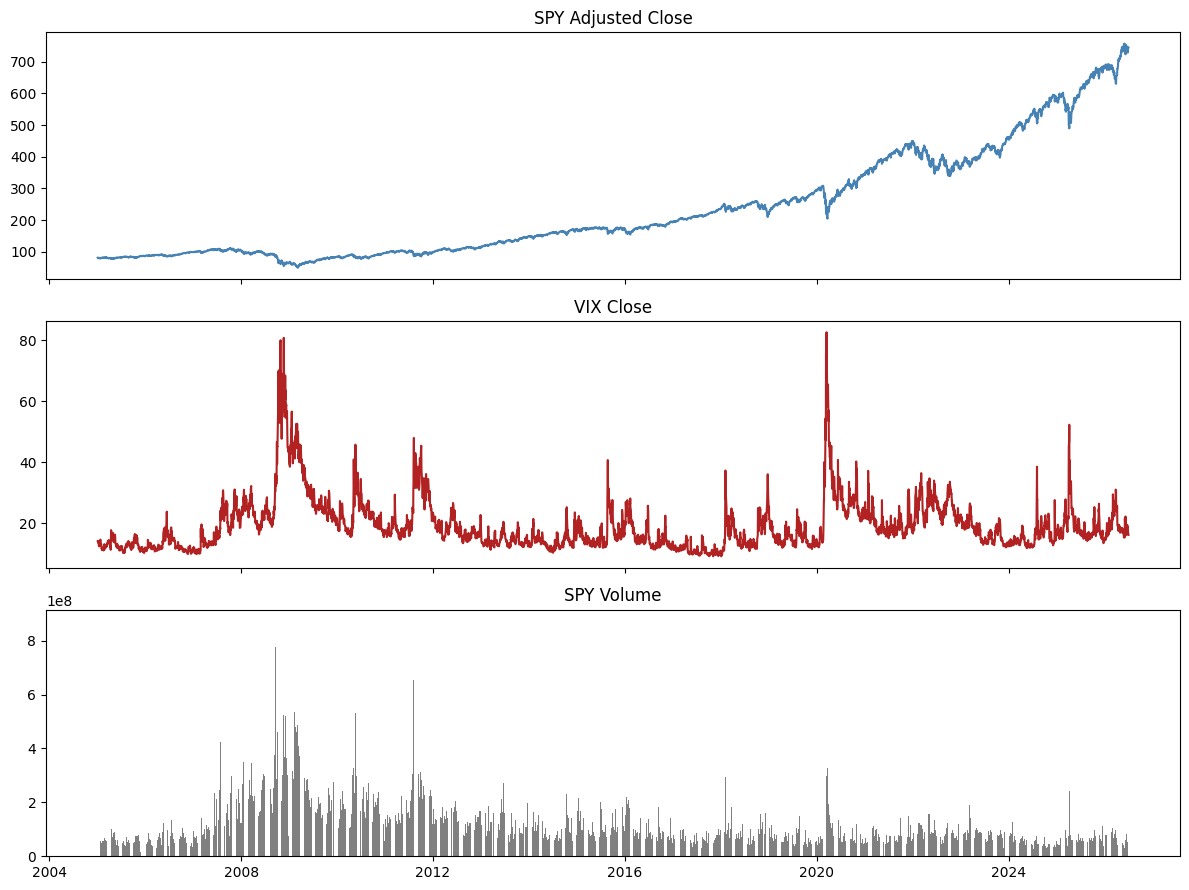

In [64]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(df.index, df["Adj Close"], color="steelblue")
axes[0].set_title("SPY Adjusted Close")

axes[1].plot(df.index, df["VIX_Close"], color="firebrick")
axes[1].set_title("VIX Close")

axes[2].bar(df.index, df["Volume"], color="gray", width=1.0)
axes[2].set_title("SPY Volume")

plt.tight_layout()
plt.show()


### 1.5 Persist raw dataset

In [65]:
out_path = os.path.join(DATA_DIR, "spy_raw.csv")
df.to_csv(out_path)
print(f"Saved {len(df)} rows to {out_path}")
print(f"Date range: {df.index.min().date()} -> {df.index.max().date()}")


Saved 5408 rows to data/spy_raw.csv
Date range: 2005-01-03 -> 2026-07-02


# 2. Feature Engineering:  SPY

Step 2 of 5. Loads `data/spy_raw.csv`  and builds the feature set consumed by
both the HMM regime model and the CNN-LSTM-Attention model:

- Return-based features (log returns, multi-horizon momentum)
- Volatility features (rolling realized vol, ATR, VIX-based)
- Trend/momentum indicators (SMA/EMA, MACD, RSI, ADX)
- Mean-reversion indicators (Bollinger Bands, z-score of price)
- Volume features
- Calendar features



In [66]:
DATA_DIR = "data"
df = pd.read_csv(os.path.join(DATA_DIR, "spy_raw.csv"), index_col="Date", parse_dates=True)
df.tail()

,Adj Close,Close,High,Low,Open,Volume,VIX_Close,TNX_Close
Date,,,,,,,,
2026-06-26,728.989990,728.989990,736.530029,716.580017,728.950012,71034000,18.410000,4.372
2026-06-29,741.000000,741.000000,741.559998,732.090027,736.530029,58035200,17.650000,4.372
2026-06-30,746.770020,746.770020,748.020020,740.890015,741.289978,55626000,16.450001,4.372
2026-07-01,745.760010,745.760010,749.440002,742.380005,745.000000,47100900,16.590000,4.372
2026-07-02,744.780029,744.780029,751.309998,740.030029,747.400024,57447800,16.150000,4.372


### 2.1 Returns

In [67]:
px = df["Adj Close"]

df["log_ret_1d"] = np.log(px / px.shift(1))
for h in [5, 10, 21, 63]:  # ~1wk, 2wk, 1mo, 1qtr trading days
    df[f"ret_{h}d"] = px.pct_change(h)

df[["log_ret_1d", "ret_5d", "ret_10d", "ret_21d", "ret_63d"]].tail()


,log_ret_1d,ret_5d,ret_10d,ret_21d,ret_63d
Date,,,,,
2026-06-26,-0.007258,-0.023770,-0.009342,-0.026107,0.132971
2026-06-29,0.016341,-0.004554,0.001562,-0.015493,0.171614
2026-06-30,0.007757,0.017980,-0.008129,-0.010293,0.184698
2026-07-01,-0.001353,0.017075,-0.003530,-0.014315,0.149677
2026-07-02,-0.001315,0.014272,0.007745,-0.016945,0.139581


### 2.2 Volatility features

In [68]:
# Realized volatility (annualized) over rolling windows, from daily log returns
for w in [5, 10, 21, 63]:
    df[f"realized_vol_{w}d"] = df["log_ret_1d"].rolling(w).std() * np.sqrt(252)

# Average True Range (captures intraday range volatility, not just close-to-close)
atr = ta.volatility.AverageTrueRange(high=df["High"], low=df["Low"], close=df["Adj Close"], window=14)
df["atr_14"] = atr.average_true_range()
df["atr_pct"] = df["atr_14"] / df["Adj Close"]

# VIX level and its change (market's own vol expectation)
df["vix_level"] = df["VIX_Close"]
df["vix_chg_5d"] = df["VIX_Close"].pct_change(5)



### 2.3 Trend / momentum indicators

In [69]:
df["sma_20"] = ta.trend.sma_indicator(df["Adj Close"], window=20)
df["sma_50"] = ta.trend.sma_indicator(df["Adj Close"], window=50)
df["sma_200"] = ta.trend.sma_indicator(df["Adj Close"], window=200)
df["ema_12"] = ta.trend.ema_indicator(df["Adj Close"], window=12)
df["ema_26"] = ta.trend.ema_indicator(df["Adj Close"], window=26)

# Price relative to moving averages (normalized, stationary-ish)
df["px_over_sma50"] = df["Adj Close"] / df["sma_50"] - 1
df["px_over_sma200"] = df["Adj Close"] / df["sma_200"] - 1
df["sma50_over_sma200"] = df["sma_50"] / df["sma_200"] - 1   # golden/death cross proxy

macd = ta.trend.MACD(df["Adj Close"])
df["macd"] = macd.macd()
df["macd_signal"] = macd.macd_signal()
df["macd_diff"] = macd.macd_diff()

df["rsi_14"] = ta.momentum.RSIIndicator(df["Adj Close"], window=14).rsi()
df["adx_14"] = ta.trend.ADXIndicator(df["High"], df["Low"], df["Adj Close"], window=14).adx()


### 2.4 Mean-reversion indicators

In [70]:
bb = ta.volatility.BollingerBands(df["Adj Close"], window=20, window_dev=2)
df["bb_high"] = bb.bollinger_hband()
df["bb_low"] = bb.bollinger_lband()
df["bb_pct"] = bb.bollinger_pband()      # 0 = at lower band, 1 = at upper band
df["bb_width"] = bb.bollinger_wband()

# Rolling z-score of price vs its own 20d mean
roll_mean = df["Adj Close"].rolling(20).mean()
roll_std = df["Adj Close"].rolling(20).std()
df["price_zscore_20d"] = (df["Adj Close"] - roll_mean) / roll_std


### 2.5 Volume features

In [71]:
df["vol_sma_20"] = df["Volume"].rolling(20).mean()
df["vol_ratio_20"] = df["Volume"] / df["vol_sma_20"]
df["obv"] = ta.volume.OnBalanceVolumeIndicator(df["Adj Close"], df["Volume"]).on_balance_volume()
df["obv_chg_10d"] = df["obv"].pct_change(10)


### 2.6 Calendar features (cyclical encoding)

In [72]:
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 5)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 5)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)


### 2.7 Target variables

Define prediction targets for the CNN-LSTM-Attention model (next-day direction and next-day return).

In [73]:
df["target_ret_1d_fwd"] = df["log_ret_1d"].shift(-1)          # regression target
df["target_dir_1d_fwd"] = (df["target_ret_1d_fwd"] > 0).astype(int)  # classification target


### 2.8 Clean up and inspect

In [74]:
feature_cols = [c for c in df.columns if c not in
                ["Open", "High", "Low", "Close", "Adj Close", "Volume", "VIX_Close", "TNX_Close",
                 "target_ret_1d_fwd", "target_dir_1d_fwd"]]

print(f"{len(feature_cols)} engineered features")

# Warm-up period (rolling windows up to 200d) produces NaNs at the start; the final row has no forward target
df_feat = df.dropna().copy()
print(f"Rows before dropna: {len(df)}, after: {len(df_feat)}")
df_feat[feature_cols].describe().T.head(15)


41 engineered features
Rows before dropna: 5408, after: 5208


,count,mean,std,min,25%,50%,75%,max
log_ret_1d,5208.0,0.000426,0.012108,-0.115886,-0.003944,0.000717,0.005879,0.135577
ret_5d,5208.0,0.002427,0.024251,-0.197934,-0.008027,0.004172,0.015027,0.194036
ret_10d,5208.0,0.004793,0.032728,-0.267687,-0.008915,0.007998,0.022277,0.215805
ret_21d,5208.0,0.010014,0.046474,-0.327513,-0.010424,0.016015,0.036035,0.251850
ret_63d,5208.0,0.029481,0.076023,-0.414680,-0.005025,0.040728,0.074354,0.399359
realized_vol_5d,5208.0,0.149427,0.127621,0.006758,0.074290,0.118139,0.183145,1.461644
realized_vol_10d,5208.0,0.154880,0.118048,0.020060,0.085393,0.126076,0.184276,1.130632
realized_vol_21d,5208.0,0.158353,0.110976,0.034158,0.093621,0.131152,0.185662,0.936684
realized_vol_63d,5208.0,0.164191,0.100597,0.051387,0.108806,0.132948,0.188191,0.739068
atr_14,5208.0,29.796899,8.389396,7.026413,27.706964,30.660271,34.352828,45.902214


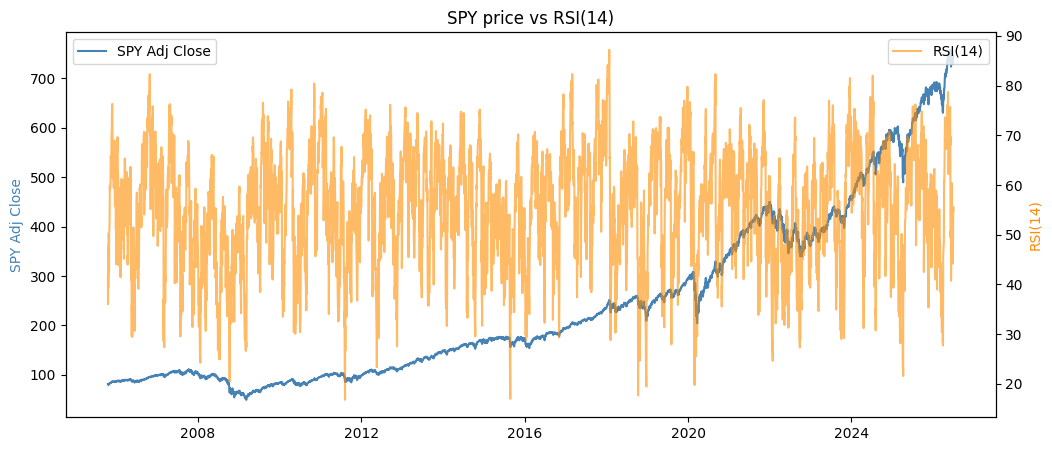

In [75]:
fig, ax = plt.subplots(figsize=(12, 5))
ax2 = ax.twinx()
ax.plot(df_feat.index, df_feat["Adj Close"], color="steelblue", label="SPY Adj Close")
ax2.plot(df_feat.index, df_feat["rsi_14"], color="darkorange", alpha=0.6, label="RSI(14)")
ax.set_ylabel("SPY Adj Close", color="steelblue")
ax2.set_ylabel("RSI(14)", color="darkorange")
ax.set_title("SPY price vs RSI(14)")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()


### 2.9 Persist engineered dataset

In [76]:
out_path = os.path.join(DATA_DIR, "spy_features.csv")
df_feat.to_csv(out_path)

meta = {"feature_cols": feature_cols,
        "target_cols": ["target_ret_1d_fwd", "target_dir_1d_fwd"]}
import json
with open(os.path.join(DATA_DIR, "feature_meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

print(f"Saved {len(df_feat)} rows x {df_feat.shape[1]} cols -> {out_path}")


Saved 5208 rows x 51 cols -> data/spy_features.csv
